# MLOps Assignment 1

**Name:** Sushantak Parashar Jha  
**Roll no:** M25CSA035

## Objective
This notebook contains experiments for training deep learning and classical machine learning models on MNIST and FashionMNIST datasets using PyTorch and Scikit-learn. All experiments are executed sequentially with detailed analysis.


In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn thop --quiet


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn import svm
from sklearn.metrics import accuracy_score

from thop import profile

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Mixed Precision Training (AMP)

All deep learning experiments use Automatic Mixed Precision (AMP) to reduce memory usage and improve training speed, as specified in the assignment.


In [ ]:
scaler = torch.cuda.amp.GradScaler()
USE_AMP = True


/tmp/ipython-input-4182212442.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## Dataset Preparation

We use MNIST and FashionMNIST datasets. Each dataset is split into:
- 70% Training
- 10% Validation
- 20% Testing

The same preprocessing and splitting strategy is used across all experiments to ensure fair comparison.


In [ ]:
# Common image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Required for ResNet
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
def load_dataset(dataset_name):
    if dataset_name == "MNIST":
        dataset = datasets.MNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform
        )
        test_dataset = datasets.MNIST(
            root="./data",
            train=False,
            download=True,
            transform=transform
        )
    elif dataset_name == "FashionMNIST":
        dataset = datasets.FashionMNIST(
            root="./data",
            train=True,
            download=True,
            transform=transform
        )
        test_dataset = datasets.FashionMNIST(
            root="./data",
            train=False,
            download=True,
            transform=transform
        )
    else:
        raise ValueError("Invalid dataset name")

    return dataset, test_dataset


In [ ]:
def split_dataset(dataset):
    total_size = len(dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.1 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )

    return train_dataset, val_dataset, test_dataset


In [ ]:
def create_dataloaders(train_ds, val_ds, test_ds, batch_size, pin_memory):
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader


In [ ]:
# Test with MNIST
mnist_full, mnist_test_official = load_dataset("MNIST")
mnist_train, mnist_val, mnist_test = split_dataset(mnist_full)

print("MNIST sizes:")
print("Train:", len(mnist_train))
print("Val:", len(mnist_val))
print("Test:", len(mnist_test))


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.19MB/s]


MNIST sizes:
Train: 42000
Val: 6000
Test: 12000


## Training and Evaluation Pipeline

This section defines reusable functions for:
- Model training with AMP
- Validation and testing
- Accuracy computation
- Training time measurement

These functions are reused across all experiments to ensure consistency.


In [ ]:
def compute_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
):
    model.to(device)

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        val_acc = compute_accuracy(model, val_loader)

        train_losses.append(avg_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}, Val Acc: {val_acc:.2f}%")

    total_time = (time.time() - start_time) * 1000  # ms

    return train_losses, val_accuracies, total_time


In [ ]:
def plot_metrics(train_losses, val_accuracies, title):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, marker='o')
    plt.title("Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, marker='o')
    plt.title("Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")

    plt.suptitle(title)
    plt.show()


In [ ]:
def compute_flops(model, input_size=(1, 1, 224, 224)):
    dummy_input = torch.randn(input_size).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    return flops, params


## Experiment 1

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment serves as the baseline configuration for MNIST classification.


In [ ]:
def get_resnet18(num_classes):
    model = models.resnet18(pretrained=False)

    # Modify first conv layer for single-channel input
    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [ ]:
# Load MNIST
mnist_full, _ = load_dataset("MNIST")
mnist_train, mnist_val, mnist_test = split_dataset(mnist_full)

# DataLoaders
batch_size = 16
pin_memory = False

train_loader, val_loader, test_loader = create_dataloaders(
    mnist_train, mnist_val, mnist_test,
    batch_size=batch_size,
    pin_memory=pin_memory
)


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.3883, Val Acc: 88.27%
Epoch [2/5] - Loss: 0.4181, Val Acc: 94.82%
Epoch [3/5] - Loss: 0.2189, Val Acc: 96.77%
Epoch [4/5] - Loss: 0.1507, Val Acc: 97.45%
Epoch [5/5] - Loss: 0.1227, Val Acc: 97.88%
Training Time: 504649.96 ms


In [ ]:
test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 97.90%


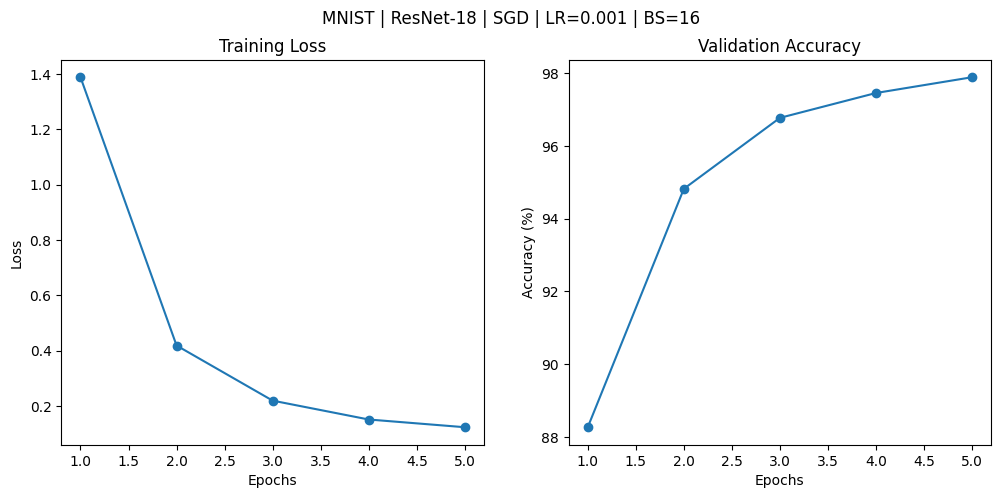

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | SGD | LR=0.001 | BS=16"
)


In [ ]:
flops, params = compute_flops(model)
print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Parameters: {params/1e6:.2f} Million")


FLOPs: 1.74 GFLOPs
Parameters: 11.18 Million


## Experiment 2

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment studies the effect of the Adam optimizer compared to SGD while keeping all other hyperparameters constant.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.1410, Val Acc: 97.95%
Epoch [2/5] - Loss: 0.0623, Val Acc: 98.57%
Epoch [3/5] - Loss: 0.0471, Val Acc: 98.47%
Epoch [4/5] - Loss: 0.0364, Val Acc: 98.85%
Epoch [5/5] - Loss: 0.0288, Val Acc: 98.95%
Training Time: 545332.58 ms


In [ ]:
test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 99.00%


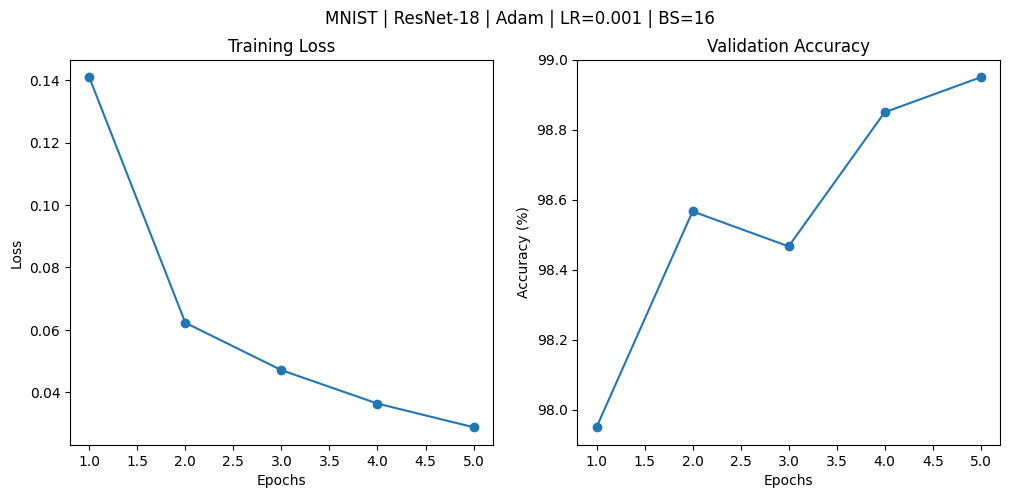

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | Adam | LR=0.001 | BS=16"
)


In [ ]:
flops, params = compute_flops(model)
print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Parameters: {params/1e6:.2f} Million")


FLOPs: 1.74 GFLOPs
Parameters: 11.18 Million


## Experiment 3

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the impact of a lower learning rate (0.0001) using SGD while keeping all other hyperparameters constant.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 2.2043, Val Acc: 37.00%
Epoch [2/5] - Loss: 1.9976, Val Acc: 50.42%
Epoch [3/5] - Loss: 1.8121, Val Acc: 60.75%
Epoch [4/5] - Loss: 1.6546, Val Acc: 67.90%
Epoch [5/5] - Loss: 1.4941, Val Acc: 75.38%
Training Time: 506061.42 ms


In [ ]:
test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 74.67%


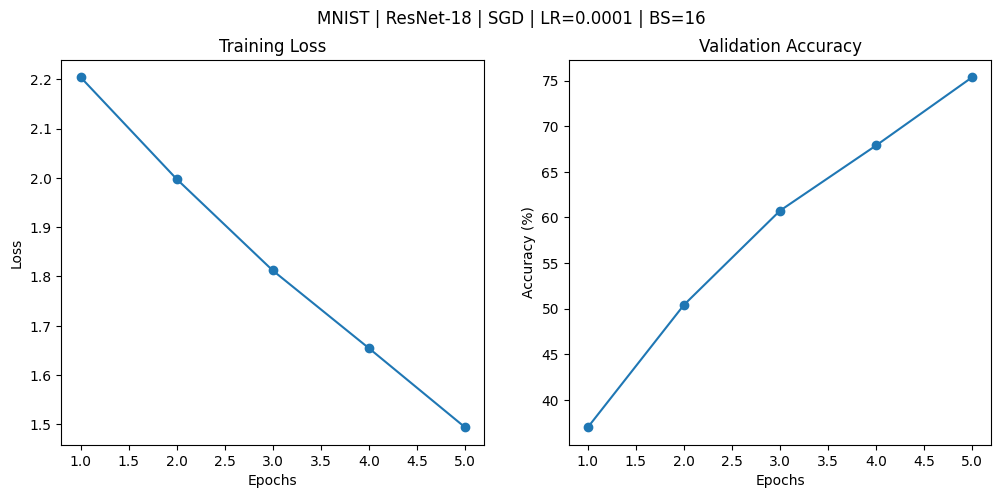

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | SGD | LR=0.0001 | BS=16"
)


In [ ]:
flops, params = compute_flops(model)
print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Parameters: {params/1e6:.2f} Million")


FLOPs: 1.74 GFLOPs
Parameters: 11.18 Million


## Experiment 4

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment analyzes the effect of a lower learning rate (0.0001) when using the Adam optimizer on MNIST.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.1388, Val Acc: 98.93%
Epoch [2/5] - Loss: 0.0473, Val Acc: 98.92%
Epoch [3/5] - Loss: 0.0356, Val Acc: 99.15%
Epoch [4/5] - Loss: 0.0306, Val Acc: 99.25%
Epoch [5/5] - Loss: 0.0242, Val Acc: 99.28%
Training Time: 543727.55 ms


In [ ]:
test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 99.07%


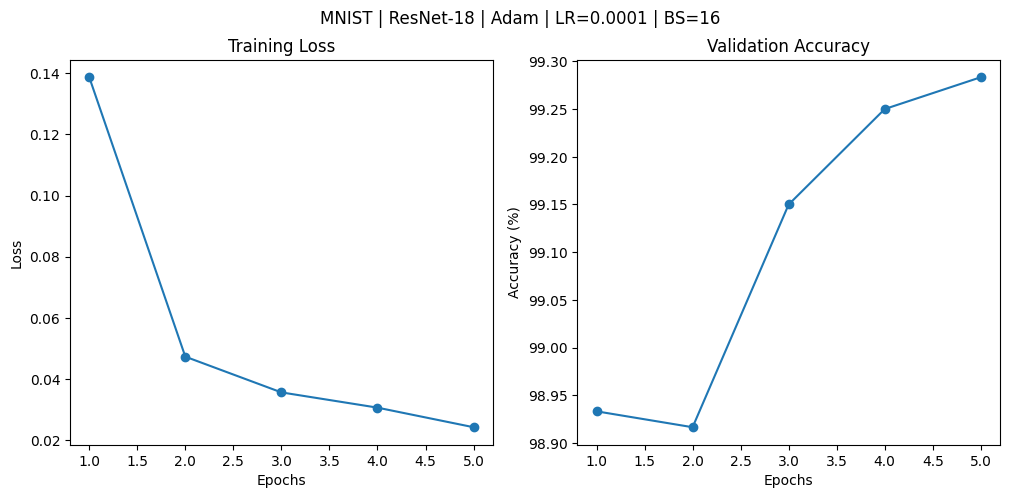

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | Adam | LR=0.0001 | BS=16"
)


In [ ]:
flops, params = compute_flops(model)
print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Parameters: {params/1e6:.2f} Million")


FLOPs: 1.74 GFLOPs
Parameters: 11.18 Million


## Experiment 5 (Epoch Comparison)

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 10  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of increasing the number of epochs from 5 to 10 using the best-performing configuration identified earlier.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses_10, val_accuracies_10, train_time_10 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
)

print(f"Training Time (10 epochs): {train_time_10:.2f} ms")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/10] - Loss: 0.1391, Val Acc: 98.15%
Epoch [2/10] - Loss: 0.0624, Val Acc: 98.95%
Epoch [3/10] - Loss: 0.0466, Val Acc: 98.98%
Epoch [4/10] - Loss: 0.0362, Val Acc: 99.02%
Epoch [5/10] - Loss: 0.0290, Val Acc: 99.05%
Epoch [6/10] - Loss: 0.0259, Val Acc: 99.37%
Epoch [7/10] - Loss: 0.0203, Val Acc: 99.35%
Epoch [8/10] - Loss: 0.0160, Val Acc: 99.35%
Epoch [9/10] - Loss: 0.0135, Val Acc: 99.37%
Epoch [10/10] - Loss: 0.0127, Val Acc: 99.42%
Training Time (10 epochs): 1077486.41 ms


In [ ]:
test_accuracy_10 = compute_accuracy(model, test_loader)
print(f"Test Accuracy (10 epochs): {test_accuracy_10:.2f}%")


Test Accuracy (10 epochs): 99.27%


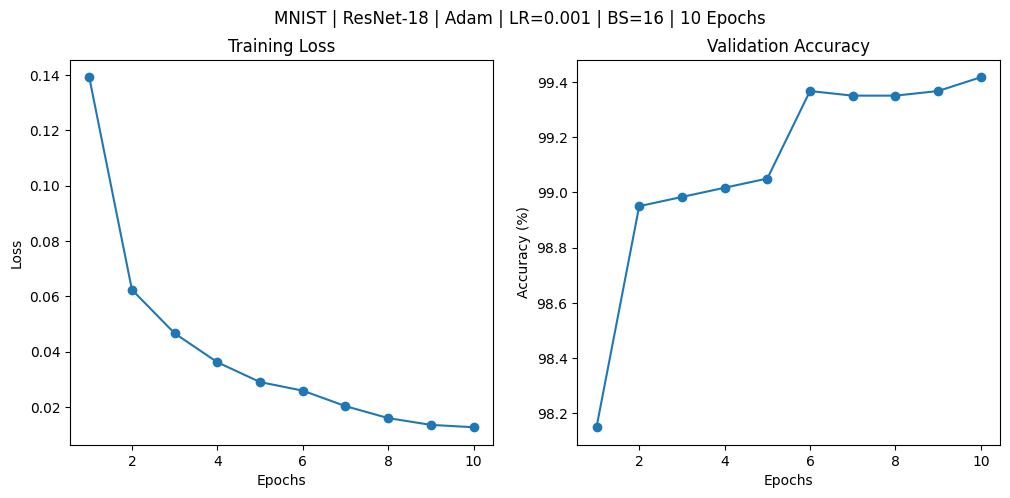

In [ ]:
plot_metrics(
    train_losses_10,
    val_accuracies_10,
    title="MNIST | ResNet-18 | Adam | LR=0.001 | BS=16 | 10 Epochs"
)


## ResNet-50 Model Definition (MNIST)

ResNet-50 is adapted for grayscale MNIST images by modifying the first convolution layer to accept single-channel input.


In [ ]:
def get_resnet50(num_classes):
    model = models.resnet50(pretrained=False)

    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


## Experiment 6

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the performance of ResNet-50 on MNIST using SGD with a learning rate of 0.001.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_acc = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.6856, Val Acc: 68.68%
Epoch [2/5] - Loss: 0.7528, Val Acc: 90.02%
Epoch [3/5] - Loss: 0.3198, Val Acc: 94.80%
Epoch [4/5] - Loss: 0.1981, Val Acc: 96.57%
Epoch [5/5] - Loss: 0.1464, Val Acc: 97.20%
Training Time: 1074583.06 ms
Test Accuracy: 97.05%


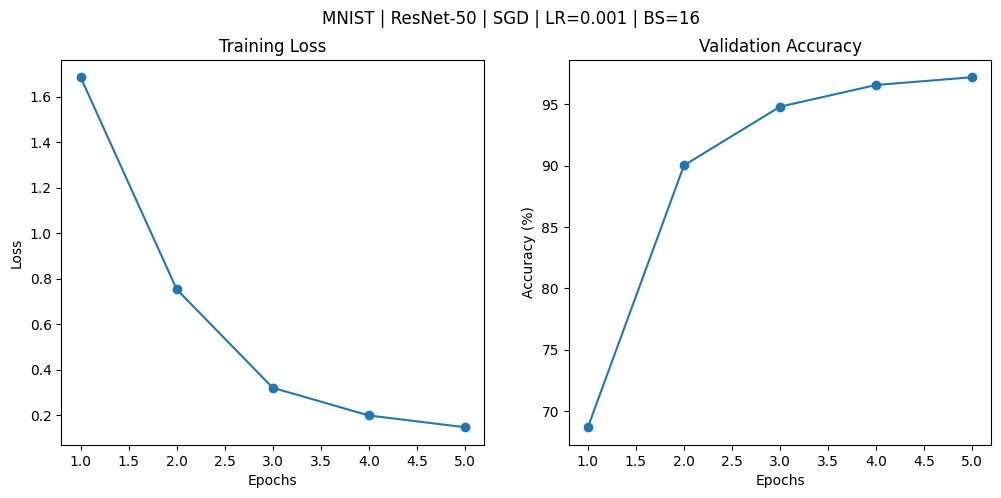

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | SGD | LR=0.001 | BS=16"
)


## Experiment 7

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the performance of ResNet-50 on MNIST using the Adam optimizer with a learning rate of 0.001.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2258, Val Acc: 96.15%
Epoch [2/5] - Loss: 0.1052, Val Acc: 98.13%
Epoch [3/5] - Loss: 0.0763, Val Acc: 98.35%
Epoch [4/5] - Loss: 0.0588, Val Acc: 98.13%
Epoch [5/5] - Loss: 0.0477, Val Acc: 98.77%
Training Time: 1160030.18 ms
Test Accuracy: 98.80%


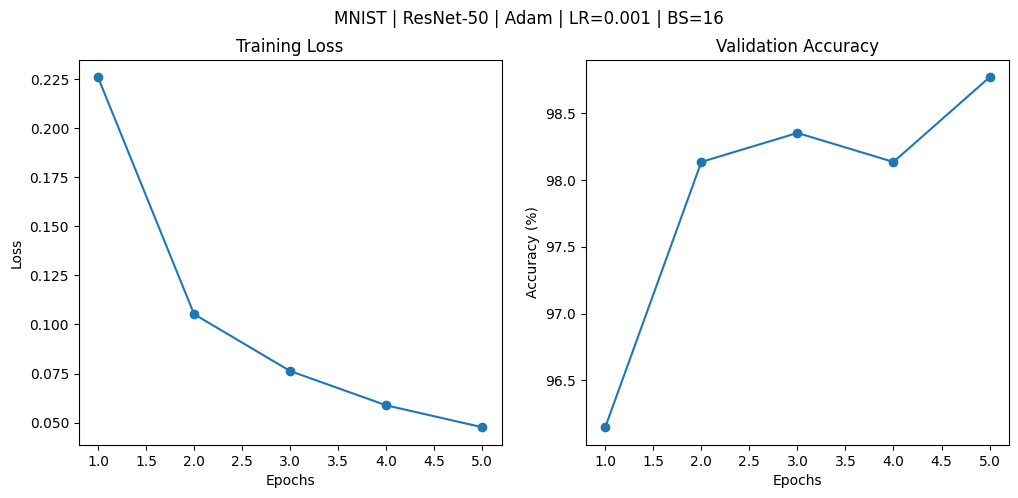

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | Adam | LR=0.001 | BS=16"
)


## Experiment 8

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.0001  
**Epochs:** 10
**pin_memory:** False  
**AMP:** Enabled  

This experiment analyzes the effect of a lower learning rate (0.0001) when training ResNet-50 on MNIST using SGD.


In [19]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/10] - Loss: 2.1444, Val Acc: 28.45%
Epoch [2/10] - Loss: 1.9147, Val Acc: 35.60%
Epoch [3/10] - Loss: 1.7877, Val Acc: 44.35%
Epoch [4/10] - Loss: 1.6937, Val Acc: 47.12%
Epoch [5/10] - Loss: 1.6101, Val Acc: 54.78%
Epoch [6/10] - Loss: 1.5136, Val Acc: 61.83%
Epoch [7/10] - Loss: 1.4098, Val Acc: 61.83%
Epoch [8/10] - Loss: 1.3002, Val Acc: 67.22%
Epoch [9/10] - Loss: 1.1886, Val Acc: 72.38%
Epoch [10/10] - Loss: 1.0781, Val Acc: 72.48%
Training Time: 2167854.69 ms
Test Accuracy: 72.47%


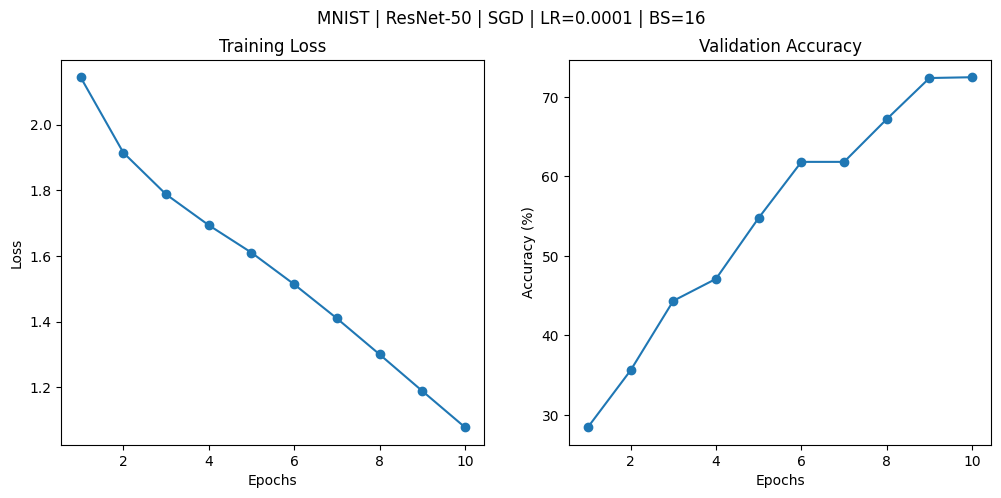

In [20]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | SGD | LR=0.0001 | BS=16"
)


## Experiment 9

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of a lower learning rate (0.0001) when training ResNet-50 on MNIST using the Adam optimizer.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2004, Val Acc: 97.50%
Epoch [2/5] - Loss: 0.0615, Val Acc: 96.95%
Epoch [3/5] - Loss: 0.0493, Val Acc: 98.77%
Epoch [4/5] - Loss: 0.0397, Val Acc: 99.00%
Epoch [5/5] - Loss: 0.0339, Val Acc: 99.05%
Training Time: 1187242.80 ms
Test Accuracy: 99.07%


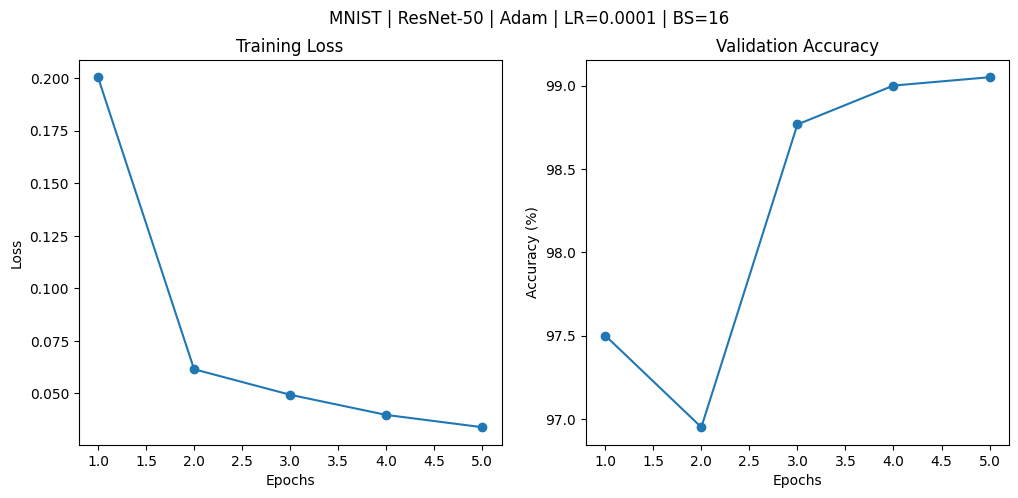

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | Adam | LR=0.0001 | BS=16"
)


## Experiment 10

**Dataset:** FashionMNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment serves as the baseline configuration for FashionMNIST classification using ResNet-18.


In [ ]:
# Load FashionMNIST
fashion_full, _ = load_dataset("FashionMNIST")
fashion_train, fashion_val, fashion_test = split_dataset(fashion_full)

# DataLoaders
batch_size = 16
pin_memory = False

train_loader, val_loader, test_loader = create_dataloaders(
    fashion_train, fashion_val, fashion_test,
    batch_size=batch_size,
    pin_memory=pin_memory
)

# Model
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.1518, Val Acc: 77.03%
Epoch [2/5] - Loss: 0.6277, Val Acc: 75.28%
Epoch [3/5] - Loss: 0.4967, Val Acc: 73.62%
Epoch [4/5] - Loss: 0.4289, Val Acc: 85.78%
Epoch [5/5] - Loss: 0.3856, Val Acc: 79.38%
Training Time: 489777.44 ms
Test Accuracy: 78.67%


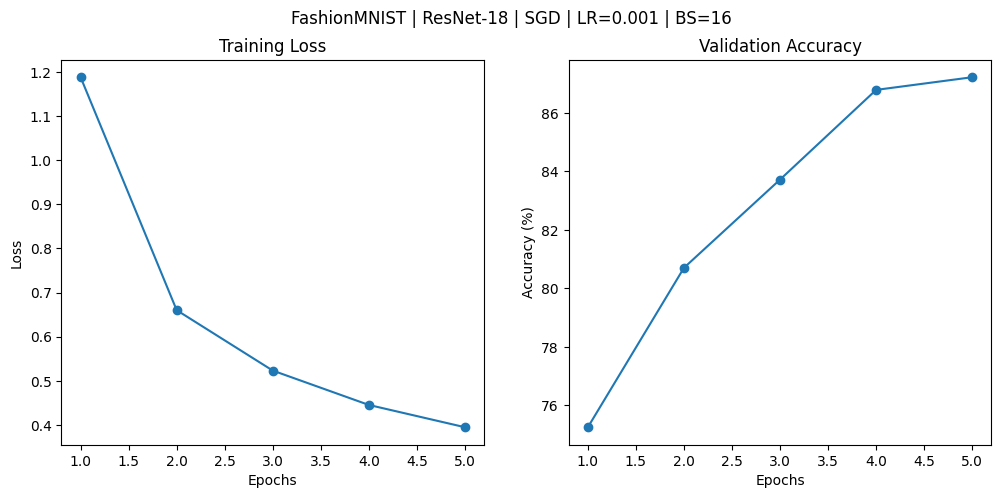

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | SGD | LR=0.001 | BS=16"
)


## Experiment 11

**Dataset:** FashionMNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of the Adam optimizer on FashionMNIST classification using ResNet-18 while keeping other hyperparameters fixed.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.4940, Val Acc: 88.03%
Epoch [2/5] - Loss: 0.3158, Val Acc: 90.82%
Epoch [3/5] - Loss: 0.2601, Val Acc: 91.78%
Epoch [4/5] - Loss: 0.2220, Val Acc: 92.10%
Epoch [5/5] - Loss: 0.1882, Val Acc: 92.95%
Training Time: 550186.87 ms
Test Accuracy: 92.99%


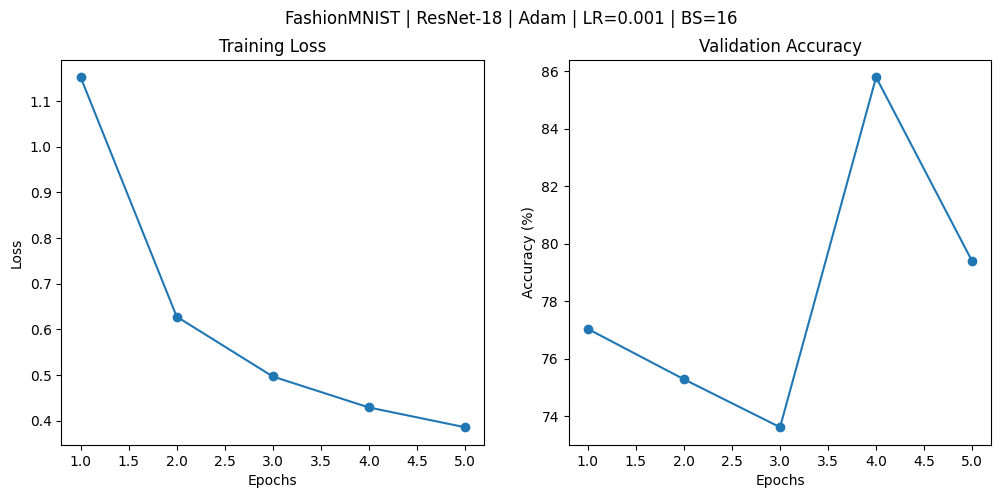

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | Adam | LR=0.001 | BS=16"
)


## Experiment 12

**Dataset:** FashionMNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment analyzes the impact of a lower learning rate (0.0001) when training ResNet-18 on FashionMNIST using SGD.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 2.0955, Val Acc: 50.95%
Epoch [2/5] - Loss: 1.6983, Val Acc: 61.93%
Epoch [3/5] - Loss: 1.4115, Val Acc: 66.88%
Epoch [4/5] - Loss: 1.2264, Val Acc: 71.43%
Epoch [5/5] - Loss: 1.0981, Val Acc: 73.23%
Training Time: 512056.07 ms
Test Accuracy: 72.75%


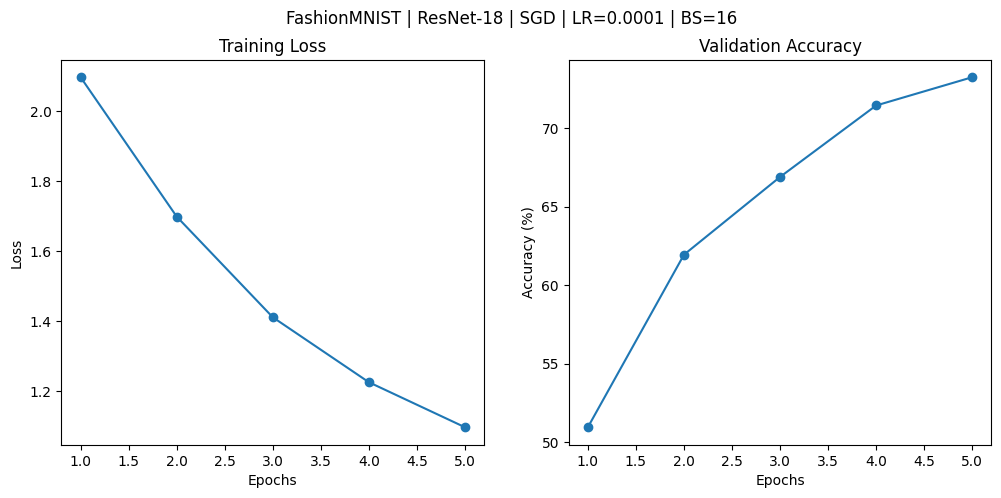

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | SGD | LR=0.0001 | BS=16"
)


## Experiment 13

**Dataset:** FashionMNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of a lower learning rate (0.0001) when training ResNet-18 on FashionMNIST using the Adam optimizer.


In [ ]:
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.4398, Val Acc: 90.48%
Epoch [2/5] - Loss: 0.2694, Val Acc: 92.05%
Epoch [3/5] - Loss: 0.2159, Val Acc: 92.42%
Epoch [4/5] - Loss: 0.1773, Val Acc: 92.90%
Epoch [5/5] - Loss: 0.1417, Val Acc: 91.98%
Training Time: 554598.16 ms
Test Accuracy: 92.01%


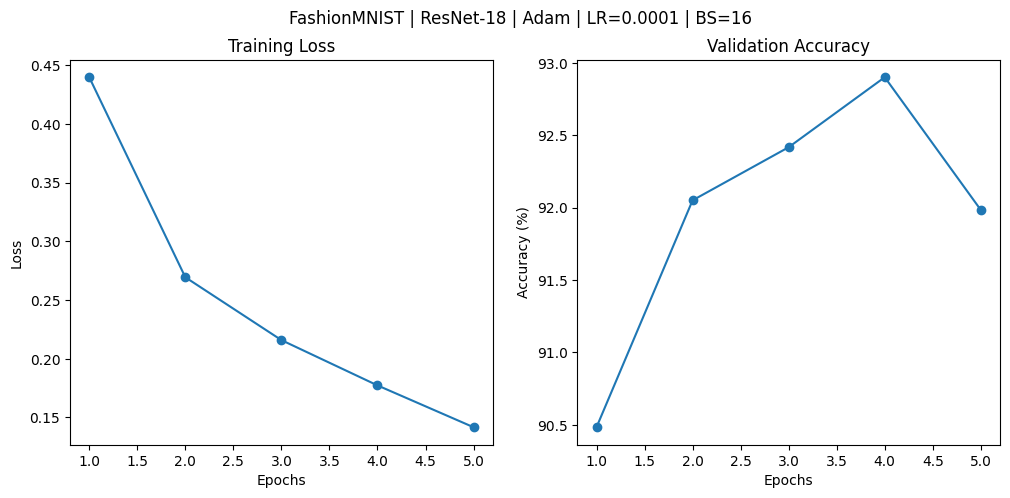

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | Adam | LR=0.0001 | BS=16"
)


## Experiment 14

**Dataset:** FashionMNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the baseline performance of ResNet-50 on FashionMNIST using SGD with a learning rate of 0.001.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.5214, Val Acc: 63.97%
Epoch [2/5] - Loss: 0.9500, Val Acc: 65.90%
Epoch [3/5] - Loss: 0.7641, Val Acc: 76.00%
Epoch [4/5] - Loss: 0.6416, Val Acc: 80.22%
Epoch [5/5] - Loss: 0.5594, Val Acc: 82.42%
Training Time: 1101645.55 ms
Test Accuracy: 81.62%


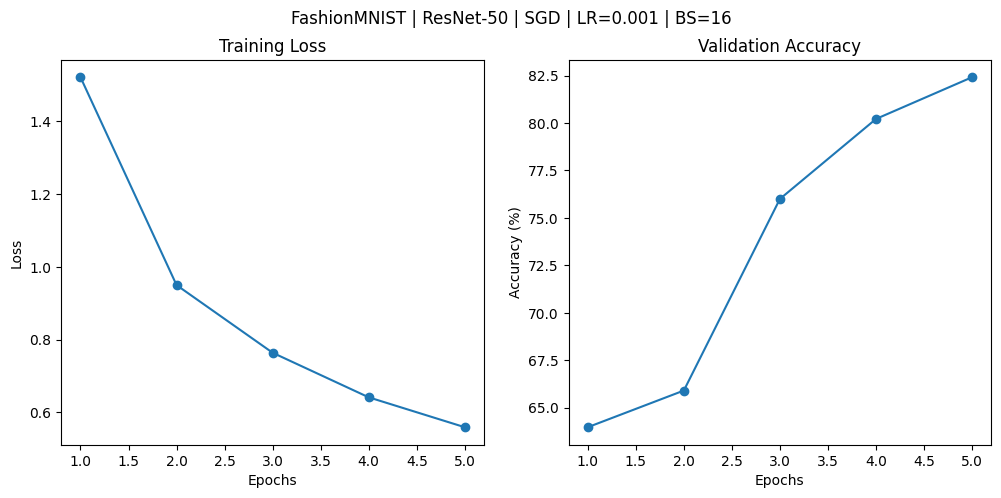

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | SGD | LR=0.001 | BS=16"
)


## Experiment 15

**Dataset:** FashionMNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the performance of ResNet-50 on FashionMNIST using the Adam optimizer with a learning rate of 0.001.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2242, Val Acc: 96.62%
Epoch [2/5] - Loss: 0.1005, Val Acc: 95.72%
Epoch [3/5] - Loss: 0.0735, Val Acc: 98.27%
Epoch [4/5] - Loss: 0.0588, Val Acc: 98.95%
Epoch [5/5] - Loss: 0.0442, Val Acc: 98.67%
Training Time: 1180791.68 ms
Test Accuracy: 98.78%


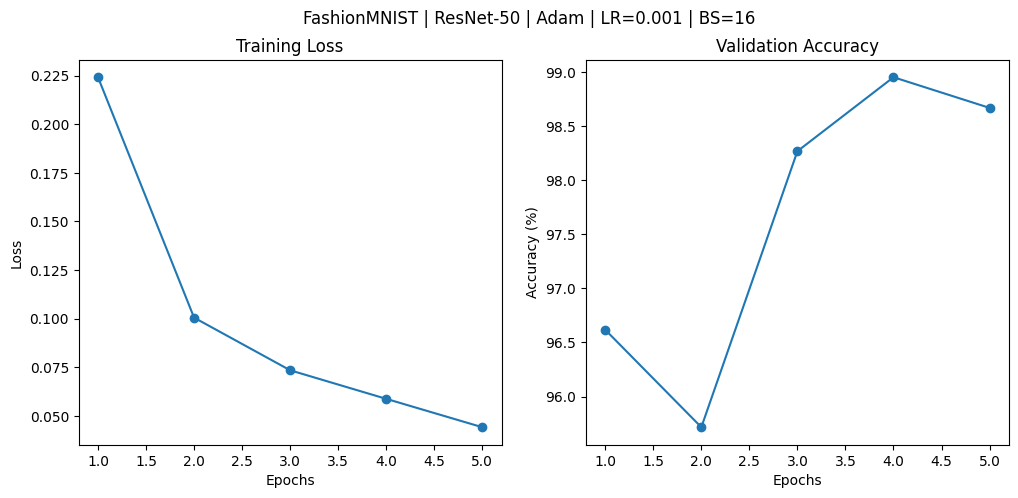

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | Adam | LR=0.001 | BS=16"
)


## Experiment 16

**Dataset:** FashionMNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.0001  
**Epochs:** 10  
**pin_memory:** False  
**AMP:** Enabled  

This experiment analyzes the effect of a lower learning rate (0.0001) when training ResNet-50 on FashionMNIST using SGD.


In [21]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/10] - Loss: 2.1708, Val Acc: 27.93%
Epoch [2/10] - Loss: 1.9268, Val Acc: 35.75%
Epoch [3/10] - Loss: 1.7984, Val Acc: 43.65%
Epoch [4/10] - Loss: 1.7056, Val Acc: 51.95%
Epoch [5/10] - Loss: 1.6214, Val Acc: 54.20%
Epoch [6/10] - Loss: 1.5296, Val Acc: 58.23%
Epoch [7/10] - Loss: 1.4370, Val Acc: 60.03%
Epoch [8/10] - Loss: 1.3309, Val Acc: 65.25%
Epoch [9/10] - Loss: 1.2315, Val Acc: 68.70%
Epoch [10/10] - Loss: 1.1343, Val Acc: 70.77%
Training Time: 2145818.99 ms
Test Accuracy: 70.84%


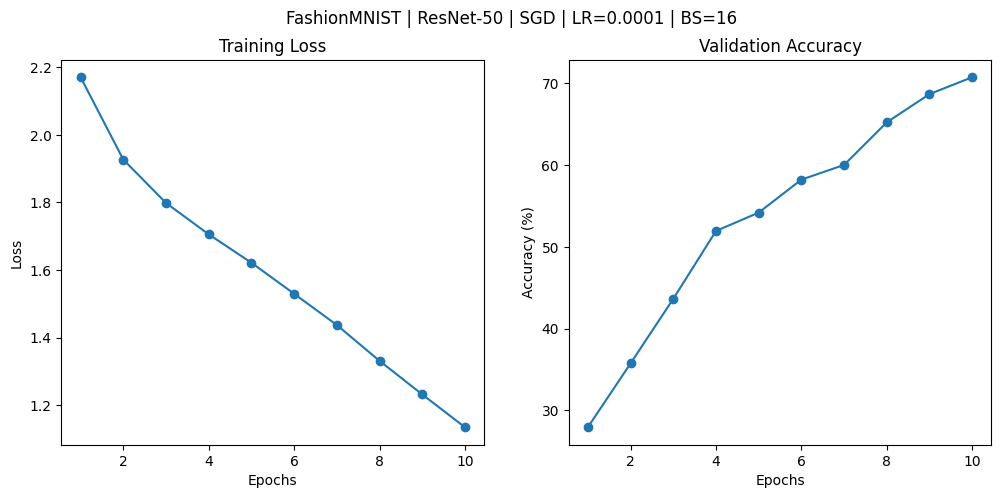

In [22]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | SGD | LR=0.0001 | BS=16"
)


## Experiment 17

**Dataset:** FashionMNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 16  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of a lower learning rate (0.0001) when training ResNet-50 on FashionMNIST using the Adam optimizer.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2047, Val Acc: 98.53%
Epoch [2/5] - Loss: 0.0608, Val Acc: 98.92%
Epoch [3/5] - Loss: 0.0509, Val Acc: 98.88%
Epoch [4/5] - Loss: 0.0398, Val Acc: 99.00%
Epoch [5/5] - Loss: 0.0358, Val Acc: 99.22%
Training Time: 1176574.64 ms
Test Accuracy: 99.18%


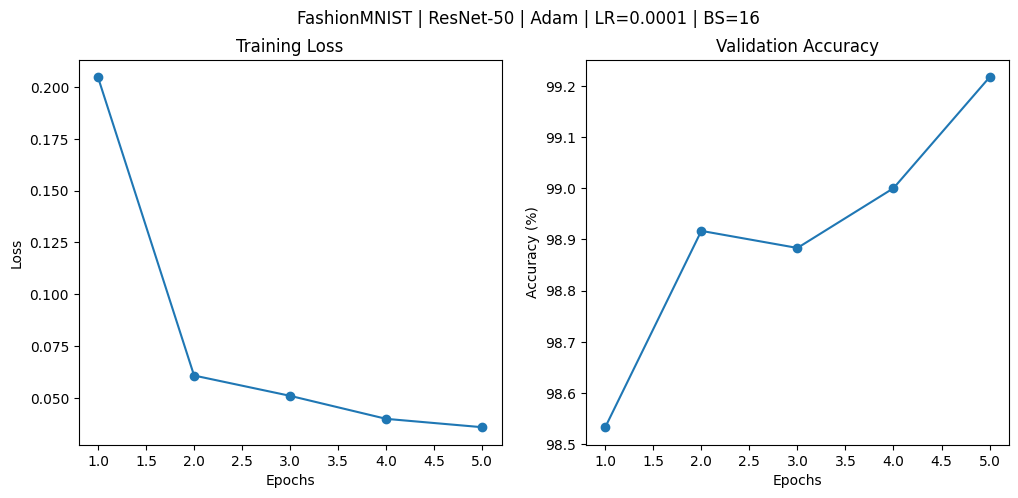

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | Adam | LR=0.0001 | BS=16"
)


## Experiment 18

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 32  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of increasing the batch size from 16 to 32 for ResNet-18 on MNIST using SGD with a learning rate of 0.001.


In [ ]:
# Model
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time (ms): {train_time:.2f}")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy (%): {test_accuracy:.2f}")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.8175, Val Acc: 73.03%
Epoch [2/5] - Loss: 0.9845, Val Acc: 86.53%
Epoch [3/5] - Loss: 0.4617, Val Acc: 93.93%
Epoch [4/5] - Loss: 0.2806, Val Acc: 95.88%
Epoch [5/5] - Loss: 0.2022, Val Acc: 96.17%
Training Time (ms): 458475.31
Test Accuracy (%): 96.15


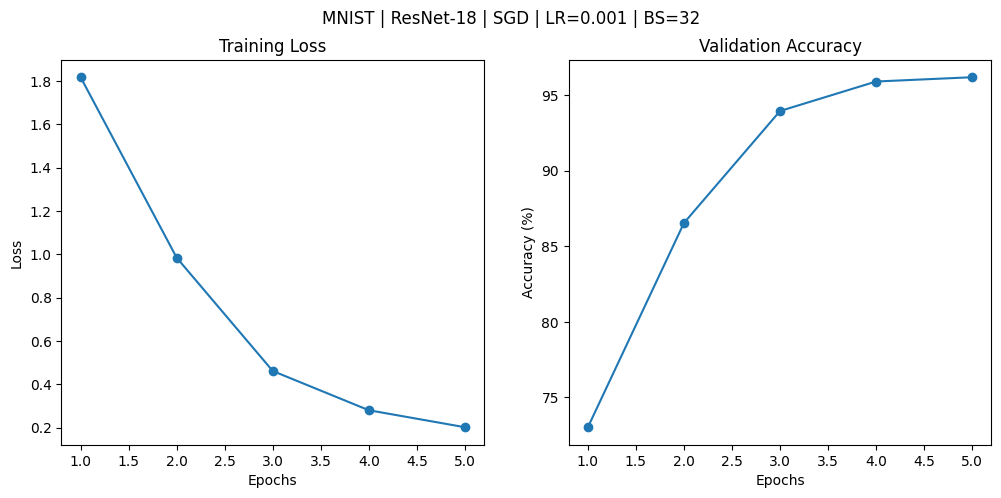

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | SGD | LR=0.001 | BS=32"
)


## Experiment 19

**Dataset:** MNIST  
**Model:** ResNet-18 (pretrained = False)  
**Batch Size:** 32  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of increasing the batch size to 32 for ResNet-18 on MNIST using the Adam optimizer with a learning rate of 0.0001.


In [ ]:
# Dataloaders with batch size = 32 (MNIST)
batch_size = 32
pin_memory = False

train_loader, val_loader, test_loader = create_dataloaders(
    mnist_train, mnist_val, mnist_test,
    batch_size=batch_size,
    pin_memory=pin_memory
)

# Model
model = get_resnet18(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.1444, Val Acc: 98.47%
Epoch [2/5] - Loss: 0.0399, Val Acc: 99.10%
Epoch [3/5] - Loss: 0.0314, Val Acc: 98.73%
Epoch [4/5] - Loss: 0.0265, Val Acc: 98.62%
Epoch [5/5] - Loss: 0.0208, Val Acc: 99.27%
Training Time: 474043.47 ms
Test Accuracy: 99.27%


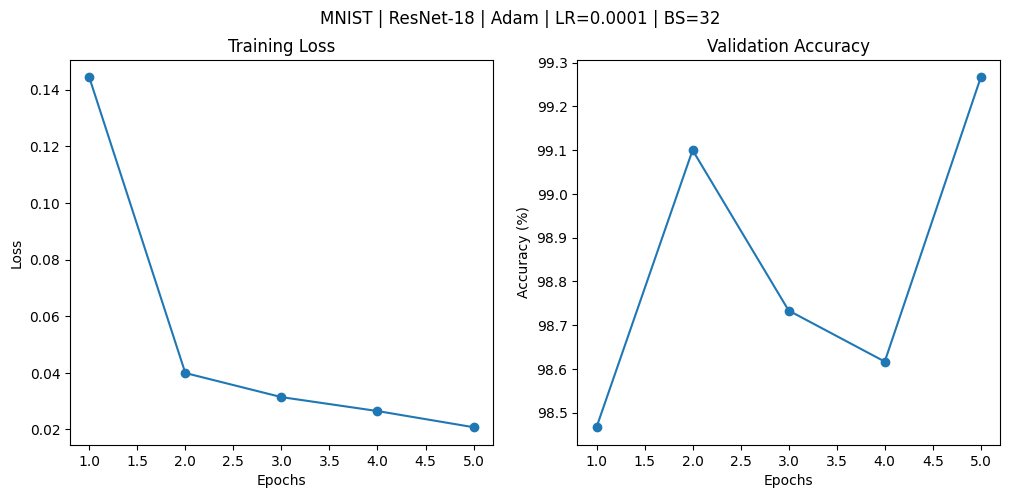

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-18 | Adam | LR=0.0001 | BS=32"
)


## Experiment 20

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 32  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the effect of increasing the batch size to 32 for ResNet-50 on MNIST using SGD with a learning rate of 0.001.


In [ ]:
# Dataloaders with batch size = 32 (MNIST)
batch_size = 32
pin_memory = False

train_loader, val_loader, test_loader = create_dataloaders(
    mnist_train, mnist_val, mnist_test,
    batch_size=batch_size,
    pin_memory=pin_memory
)

# Model
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print(f"Training Time: {train_time:.2f} ms")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.8363, Val Acc: 37.43%
Epoch [2/5] - Loss: 1.3437, Val Acc: 70.63%
Epoch [3/5] - Loss: 0.8018, Val Acc: 82.88%
Epoch [4/5] - Loss: 0.4591, Val Acc: 91.72%
Epoch [5/5] - Loss: 0.2985, Val Acc: 94.25%
Training Time: 1031597.92 ms
Test Accuracy: 94.28%


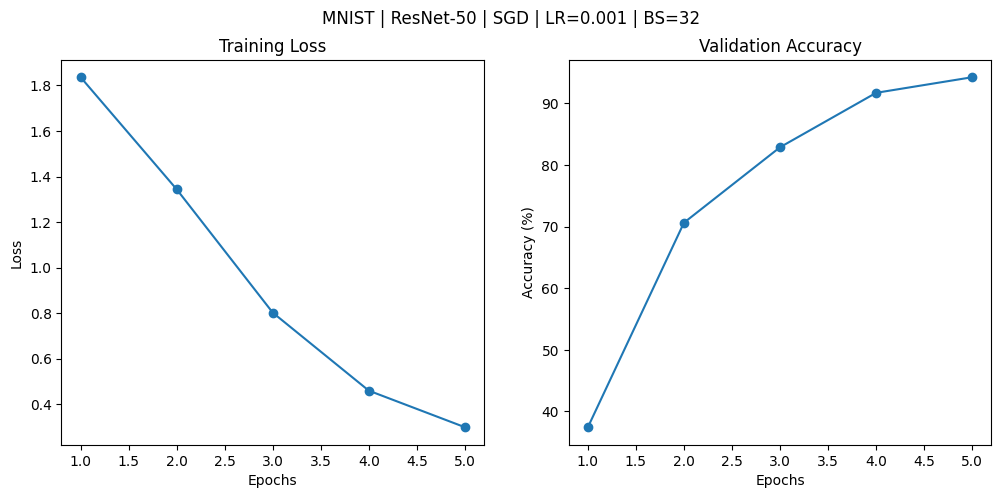

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | SGD | LR=0.001 | BS=32"
)


## Experiment 21

**Dataset:** MNIST  
**Model:** ResNet-50 (pretrained = False)  
**Batch Size:** 32  
**Optimizer:** Adam  
**Learning Rate:** 0.0001  
**Epochs:** 5  
**pin_memory:** False  
**AMP:** Enabled  

This experiment evaluates the impact of increasing the batch size from 16 to 32 for ResNet-50 on the MNIST dataset when trained using the Adam optimizer with a lower learning rate (0.0001). The objective is to study how batch size scaling affects convergence behavior, training time, and classification performance for a deeper network architecture.


In [ ]:
model = get_resnet50(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5   # use 3 if CPU is slow
)

print(f"Training Time (ms): {train_time:.2f}")

test_accuracy = compute_accuracy(model, test_loader)
print(f"Test Accuracy (%): {test_accuracy:.2f}")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2335, Val Acc: 98.33%
Epoch [2/5] - Loss: 0.0541, Val Acc: 98.58%
Epoch [3/5] - Loss: 0.0391, Val Acc: 98.62%
Epoch [4/5] - Loss: 0.0357, Val Acc: 98.85%
Epoch [5/5] - Loss: 0.0305, Val Acc: 99.17%
Training Time (ms): 1068200.15
Test Accuracy (%): 99.11


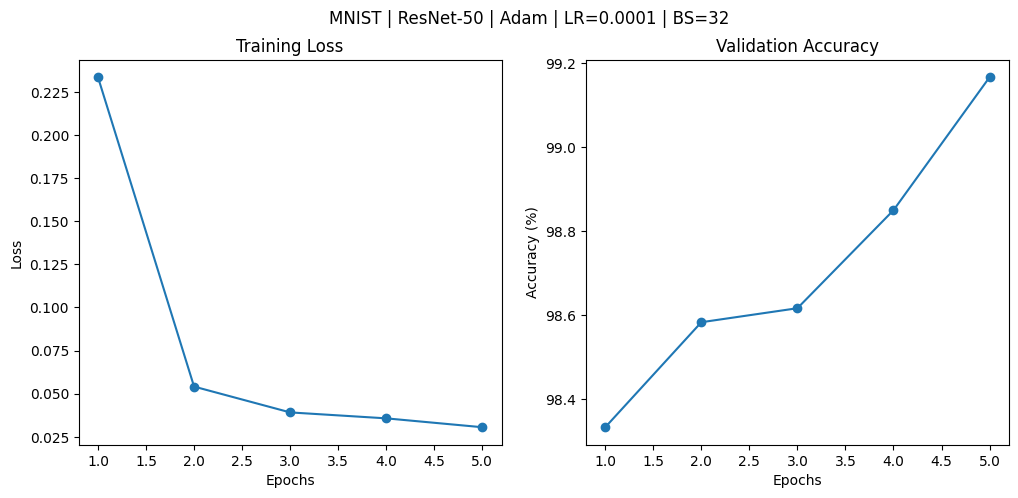

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="MNIST | ResNet-50 | Adam | LR=0.0001 | BS=32"
)


In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [ ]:
# Reduced subset for SVM (fast & safe)
def prepare_svm_data(dataset, num_samples=3000):
    X = []
    y = []

    for i in range(num_samples):
        img, label = dataset[i]
        X.append(img.view(-1).numpy())
        y.append(label)

    return np.array(X), np.array(y)

# MNIST data for SVM
X_train, y_train = prepare_svm_data(mnist_train, num_samples=3000)
X_test, y_test = prepare_svm_data(mnist_test, num_samples=1000)

print(X_train.shape, X_test.shape)


(3000, 50176) (1000, 50176)


## SVM Experiment 1

**Dataset:** MNIST  
**Classifier:** Support Vector Machine (SVM)  
**Kernel:** RBF  

This experiment evaluates an SVM classifier with an RBF kernel on a reduced subset of the MNIST dataset to ensure feasible training time.


In [ ]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"SVM (RBF) MNIST Accuracy: {accuracy * 100:.2f}%")


SVM (RBF) MNIST Accuracy: 93.90%


## SVM Experiment 2

**Dataset:** MNIST  
**Classifier:** Support Vector Machine (SVM)  
**Kernel:** Polynomial  

This experiment evaluates an SVM classifier with a polynomial kernel on a reduced subset of the MNIST dataset, using the same data as the RBF kernel experiment for fair comparison.


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Polynomial kernel SVM (degree = 3)
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

y_pred = svm_poly.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"SVM (Polynomial) MNIST Accuracy: {accuracy * 100:.2f}%")


SVM (Polynomial) MNIST Accuracy: 94.20%


## SVM Experiment 3

**Dataset:** FashionMNIST  
**Classifier:** Support Vector Machine (SVM)  
**Kernel:** RBF  

This experiment evaluates the performance of an SVM classifier with an RBF kernel on a reduced subset of the FashionMNIST dataset.


In [ ]:
# Prepare reduced FashionMNIST data for SVM
X_train_f, y_train_f = prepare_svm_data(fashion_train, num_samples=3000)
X_test_f, y_test_f = prepare_svm_data(fashion_test, num_samples=1000)

print(X_train_f.shape, X_test_f.shape)


(3000, 50176) (1000, 50176)


In [ ]:
svm_rbf_fashion = SVC(kernel='rbf')

svm_rbf_fashion.fit(X_train_f, y_train_f)

y_pred = svm_rbf_fashion.predict(X_test_f)
accuracy = accuracy_score(y_test_f, y_pred)

print(f"SVM (RBF) FashionMNIST Accuracy: {accuracy * 100:.2f}%")


SVM (RBF) FashionMNIST Accuracy: 79.60%


## SVM Experiment 4

**Dataset:** FashionMNIST  
**Classifier:** Support Vector Machine (SVM)  
**Kernel:** Polynomial  

This experiment evaluates the performance of an SVM classifier with a polynomial kernel on a reduced subset of the FashionMNIST dataset, using the same data as the RBF kernel experiment for fair comparison.


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Polynomial kernel SVM (degree = 3)
svm_poly_fashion = SVC(kernel='poly', degree=3)

svm_poly_fashion.fit(X_train_f, y_train_f)

y_pred = svm_poly_fashion.predict(X_test_f)
accuracy = accuracy_score(y_test_f, y_pred)

print(f"SVM (Polynomial) FashionMNIST Accuracy: {accuracy * 100:.2f}%")


SVM (Polynomial) FashionMNIST Accuracy: 81.10%


## Experiment (FashionMNIST – Batch Size 32)

**Model:** ResNet-18  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  

This experiment evaluates the effect of increasing the batch size from 16 to 32 for ResNet-18 on FashionMNIST using SGD.


In [ ]:
model = get_resnet18(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

test_accuracy = compute_accuracy(model, test_loader)

print(f"ResNet-18 | SGD | BS=32 | Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.4023, Val Acc: 89.32%
Epoch [2/5] - Loss: 0.3922, Val Acc: 95.22%
Epoch [3/5] - Loss: 0.2026, Val Acc: 96.78%
Epoch [4/5] - Loss: 0.1444, Val Acc: 97.40%
Epoch [5/5] - Loss: 0.1148, Val Acc: 97.73%
ResNet-18 | SGD | BS=32 | Test Accuracy: 98.16%


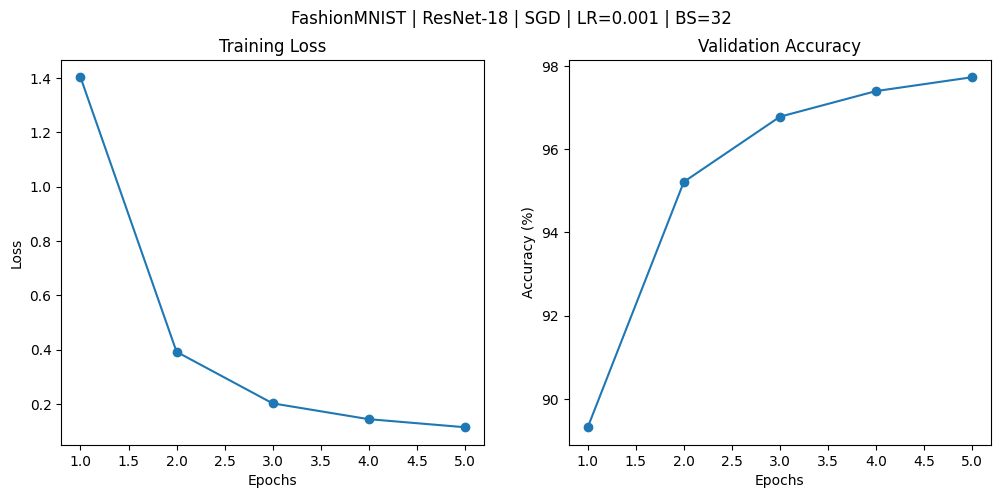

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | SGD | LR=0.001 | BS=32"
)


## Experiment (FashionMNIST – Batch Size 32)

**Model:** ResNet-18  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  

This experiment evaluates ResNet-18 on FashionMNIST with batch size 32 using the Adam optimizer.


In [ ]:
model = get_resnet18(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

test_accuracy = compute_accuracy(model, test_loader)

print(f"ResNet-18 | Adam | BS=32 | Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.1341, Val Acc: 97.38%
Epoch [2/5] - Loss: 0.0643, Val Acc: 98.82%
Epoch [3/5] - Loss: 0.0453, Val Acc: 99.00%
Epoch [4/5] - Loss: 0.0379, Val Acc: 99.08%
Epoch [5/5] - Loss: 0.0290, Val Acc: 98.77%
ResNet-18 | Adam | BS=32 | Test Accuracy: 99.19%


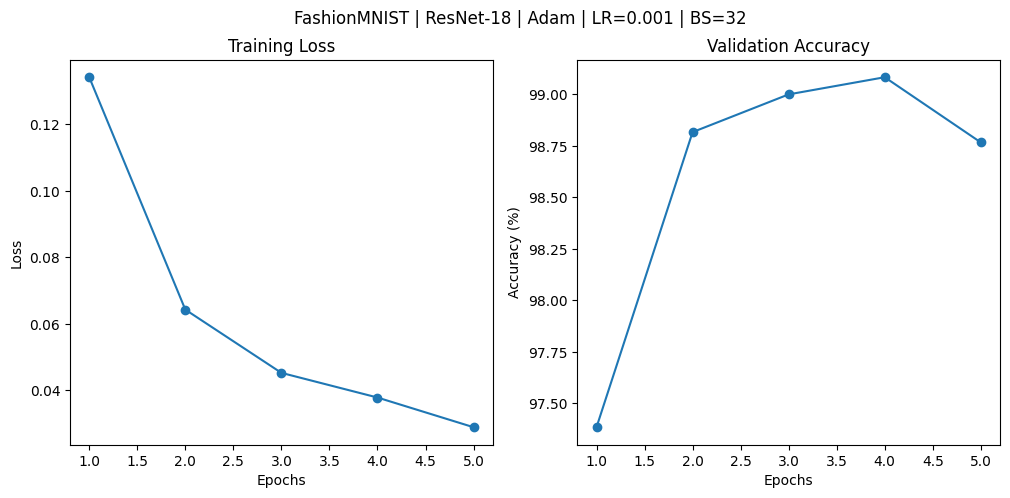

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-18 | Adam | LR=0.001 | BS=32"
)


## Experiment (FashionMNIST – Batch Size 32)

**Model:** ResNet-50  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 5  

This experiment evaluates the effect of batch size 32 on a deeper ResNet-50 model trained using SGD.


In [ ]:
model = get_resnet50(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

test_accuracy = compute_accuracy(model, test_loader)

print(f"ResNet-50 | SGD | BS=32 | Test Accuracy: {test_accuracy:.2f}%")


/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 1.6703, Val Acc: 62.48%
Epoch [2/5] - Loss: 0.8174, Val Acc: 88.52%
Epoch [3/5] - Loss: 0.3524, Val Acc: 94.67%
Epoch [4/5] - Loss: 0.2080, Val Acc: 96.40%
Epoch [5/5] - Loss: 0.1528, Val Acc: 97.17%
ResNet-50 | SGD | BS=32 | Test Accuracy: 97.37%


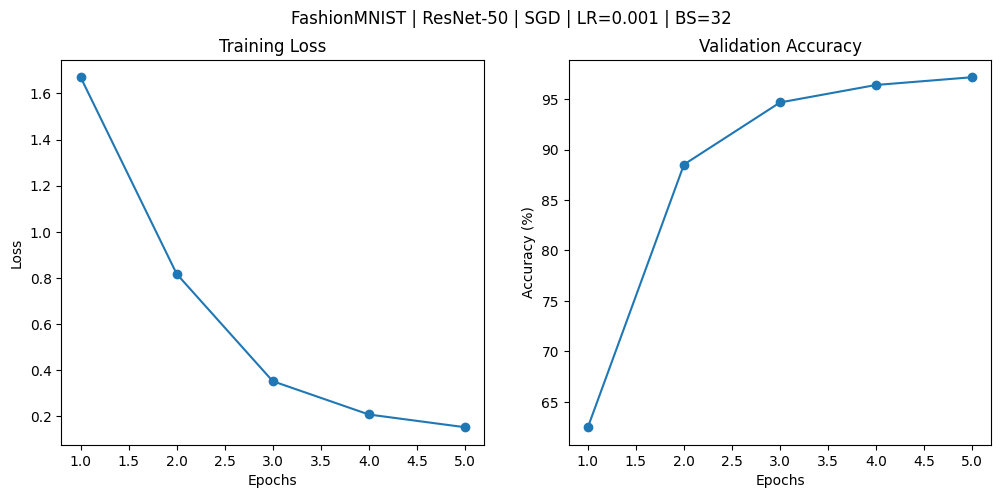

In [ ]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | SGD | LR=0.001 | BS=32"
)


## Experiment (FashionMNIST – Batch Size 32)

**Model:** ResNet-50  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 5  

This experiment evaluates the performance of ResNet-50 on FashionMNIST using batch size 32 and the Adam optimizer.


In [17]:
model = get_resnet50(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

test_accuracy = compute_accuracy(model, test_loader)

print(f"ResNet-50 | Adam | BS=32 | Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-2050023097.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/5] - Loss: 0.2385, Val Acc: 98.20%
Epoch [2/5] - Loss: 0.1046, Val Acc: 98.02%
Epoch [3/5] - Loss: 0.0755, Val Acc: 98.75%
Epoch [4/5] - Loss: 0.0559, Val Acc: 98.27%
Epoch [5/5] - Loss: 0.0463, Val Acc: 99.17%
ResNet-50 | Adam | BS=32 | Test Accuracy: 98.85%


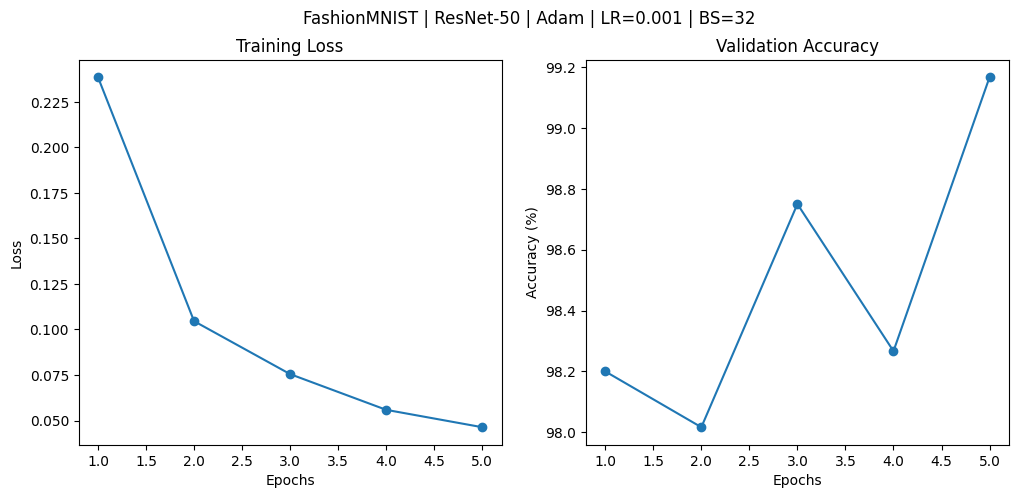

In [18]:
plot_metrics(
    train_losses,
    val_accuracies,
    title="FashionMNIST | ResNet-50 | Adam | LR=0.001 | BS=32"
)


## CPU Experiment 1

**Dataset:** FashionMNIST  
**Model:** ResNet-18 (no pretrained weights)  
**Batch Size:** 16  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 3  
**Compute:** CPU  

This experiment evaluates the feasibility and training time of training a ResNet-18 model on the FashionMNIST dataset using CPU execution only. The objective is to compare CPU-based training performance with GPU-based training in terms of computational cost and convergence behavior. The experiment is intentionally limited to a small number of epochs due to the high computational overhead of deep convolutional neural networks on CPU.


In [ ]:
model = get_resnet18(num_classes=10).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    fashion_train_loader,
    fashion_val_loader,
    criterion,
    optimizer,
    epochs=3
)

test_accuracy = compute_accuracy(model, fashion_test_loader)

print("CPU | ResNet-18 | SGD | 3 Epochs")
print(f"Train Time (ms): {train_time:.2f}")
print(f"Test Accuracy (%): {test_accuracy:.2f}")


Epoch [1/3] - Loss: 0.6127, Val Acc: 85.58%
Epoch [2/3] - Loss: 0.4068, Val Acc: 87.08%
Epoch [3/3] - Loss: 0.3456, Val Acc: 88.42%
CPU | ResNet-18 | SGD | 3 Epochs
Train Time (ms): 4100938.93
Test Accuracy (%): 87.62


## CPU Experiment 2

**Dataset:** FashionMNIST  
**Model:** ResNet-18  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 3  
**Compute:** CPU

In [ ]:
# Reuse same CPU + DataLoader settings
device = torch.device("cpu")
USE_AMP = False

# Model
model = get_resnet18(num_classes=10).to(device)

# Loss & Optimizer (Adam)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
train_losses, val_accuracies, train_time = train_model(
    model,
    fashion_train_loader,
    fashion_val_loader,
    criterion,
    optimizer,
    epochs=3
)

# Evaluate
test_accuracy = compute_accuracy(model, fashion_test_loader)

print("CPU | ResNet-18 | Adam | 3 Epochs")
print(f"Train Time (ms): {train_time:.2f}")
print(f"Test Accuracy (%): {test_accuracy:.2f}")


Epoch [1/3] - Loss: 0.5038, Val Acc: 84.12%
Epoch [2/3] - Loss: 0.3645, Val Acc: 88.85%
Epoch [3/3] - Loss: 0.3089, Val Acc: 88.50%
CPU | ResNet-18 | Adam | 3 Epochs
Train Time (ms): 5421659.86
Test Accuracy (%): 88.63


In [ ]:
model = get_resnet18(num_classes=10)
flops, params = compute_flops(model)

print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Params: {params/1e6:.2f} Million")

FLOPs: 1.82 GFLOPs
Params: 11.18 Million


## CPU Experiment 3

**Dataset:** FashionMNIST  
**Model:** ResNet-50  
**Optimizer:** SGD  
**Learning Rate:** 0.001  
**Epochs:** 1  
**Compute:** CPU


In [ ]:
device = torch.device("cpu")
USE_AMP = False

model = get_resnet50(num_classes=10).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    fashion_train_loader,
    fashion_val_loader,
    criterion,
    optimizer,
    epochs=1
)

test_accuracy = compute_accuracy(model, fashion_test_loader)

print("CPU | ResNet-50 | SGD | 1 Epoch")
print(f"Train Time (ms): {train_time:.2f}")
print(f"Test Accuracy (%): {test_accuracy:.2f}")


Epoch [1/1] - Loss: 0.9971, Val Acc: 76.93%
CPU | ResNet-50 | SGD | 1 Epoch
Train Time (ms): 2495743.50
Test Accuracy (%): 76.66


In [ ]:
model = get_resnet18(num_classes=10)
flops, params = compute_flops(model)

print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Params: {params/1e6:.2f} Million")

FLOPs: 1.82 GFLOPs
Params: 11.18 Million


## CPU Experiment 4

**Dataset:** FashionMNIST  
**Model:** ResNet-50  
**Optimizer:** Adam  
**Learning Rate:** 0.001  
**Epochs:** 1  
**Compute:** CPU


In [ ]:
model = get_resnet50(num_classes=10).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_accuracies, train_time = train_model(
    model,
    fashion_train_loader,
    fashion_val_loader,
    criterion,
    optimizer,
    epochs=1
)

test_accuracy = compute_accuracy(model, fashion_test_loader)

print("CPU | ResNet-50 | Adam | 1 Epoch")
print(f"Train Time (ms): {train_time:.2f}")
print(f"Test Accuracy (%): {test_accuracy:.2f}")


Epoch [1/1] - Loss: 0.8481, Val Acc: 83.80%
CPU | ResNet-50 | Adam | 1 Epoch
Train Time (ms): 3210639.37
Test Accuracy (%): 83.34


In [ ]:
model = get_resnet18(num_classes=10)
flops, params = compute_flops(model)

print(f"FLOPs: {flops/1e9:.2f} GFLOPs")
print(f"Params: {params/1e6:.2f} Million")

FLOPs: 1.82 GFLOPs
Params: 11.18 Million
